In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBClassifier

# Set plotting style
sns.set_theme(style="whitegrid")

#### Load the Dataset

In [ ]:
df = pd.read_csv("diabetes.csv")

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
zero_counts = (df[['Pregnancies','Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum()
print("\nCount of hidden missing values (zeros) in continuous features:")
print(zero_counts)

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Count of hidden missing values (zeros) in continuous features:
Pregnancies      111
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


### Step 4: Exploratory Data Analysis — Distributions

C:\Users\saipr\AppData\Local\Temp\ipykernel_5996\2149919849.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y="BMI", data=df, ax=axes[1], palette="Set2")


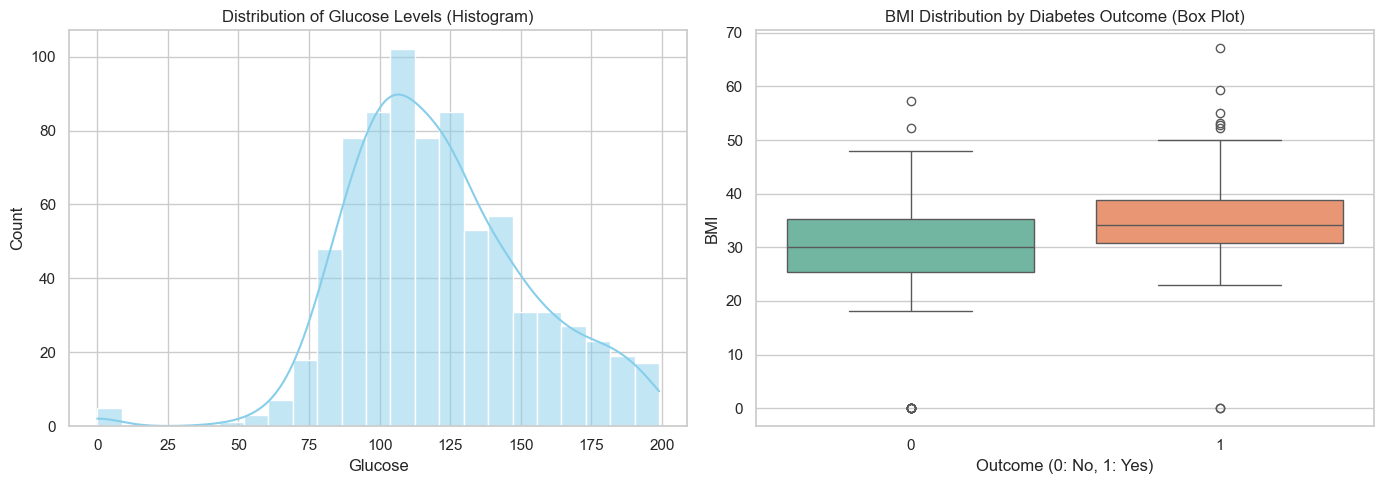

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Glucose"], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution of Glucose Levels (Histogram)")
axes[0].set_xlabel("Glucose")

sns.boxplot(x="Outcome", y="BMI", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("BMI Distribution by Diabetes Outcome (Box Plot)")
axes[1].set_xlabel("Outcome (0: No, 1: Yes)")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Award Distribution')

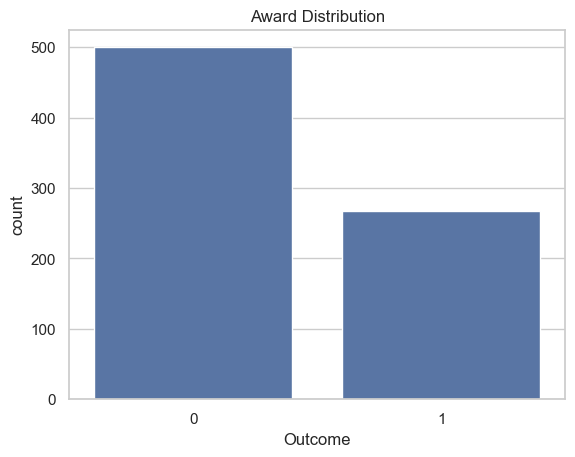

In [ ]:
sns.countplot(x=df['Outcome'])


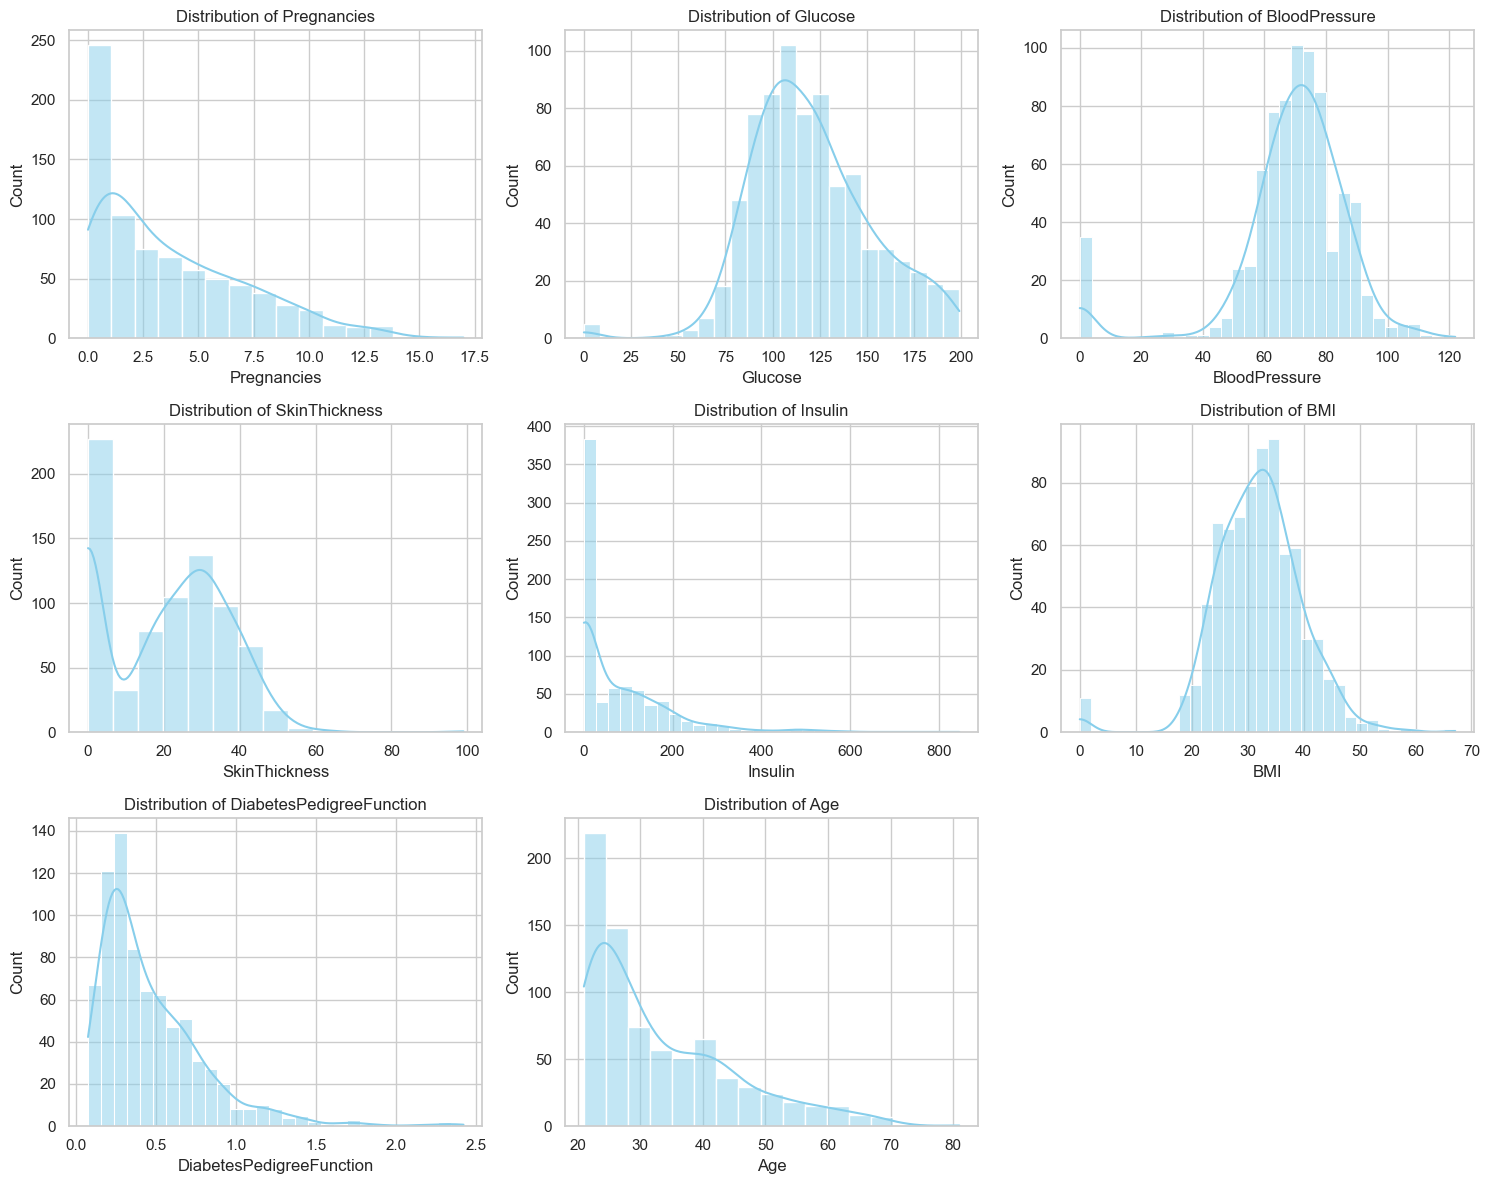

In [10]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(df.columns[:-1]): 
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

C:\Users\saipr\AppData\Local\Temp\ipykernel_5996\1930504903.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True, color='skyblue')
C:\Users\saipr\AppData\Local\Temp\ipykernel_5996\1930504903.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True, color='skyblue')


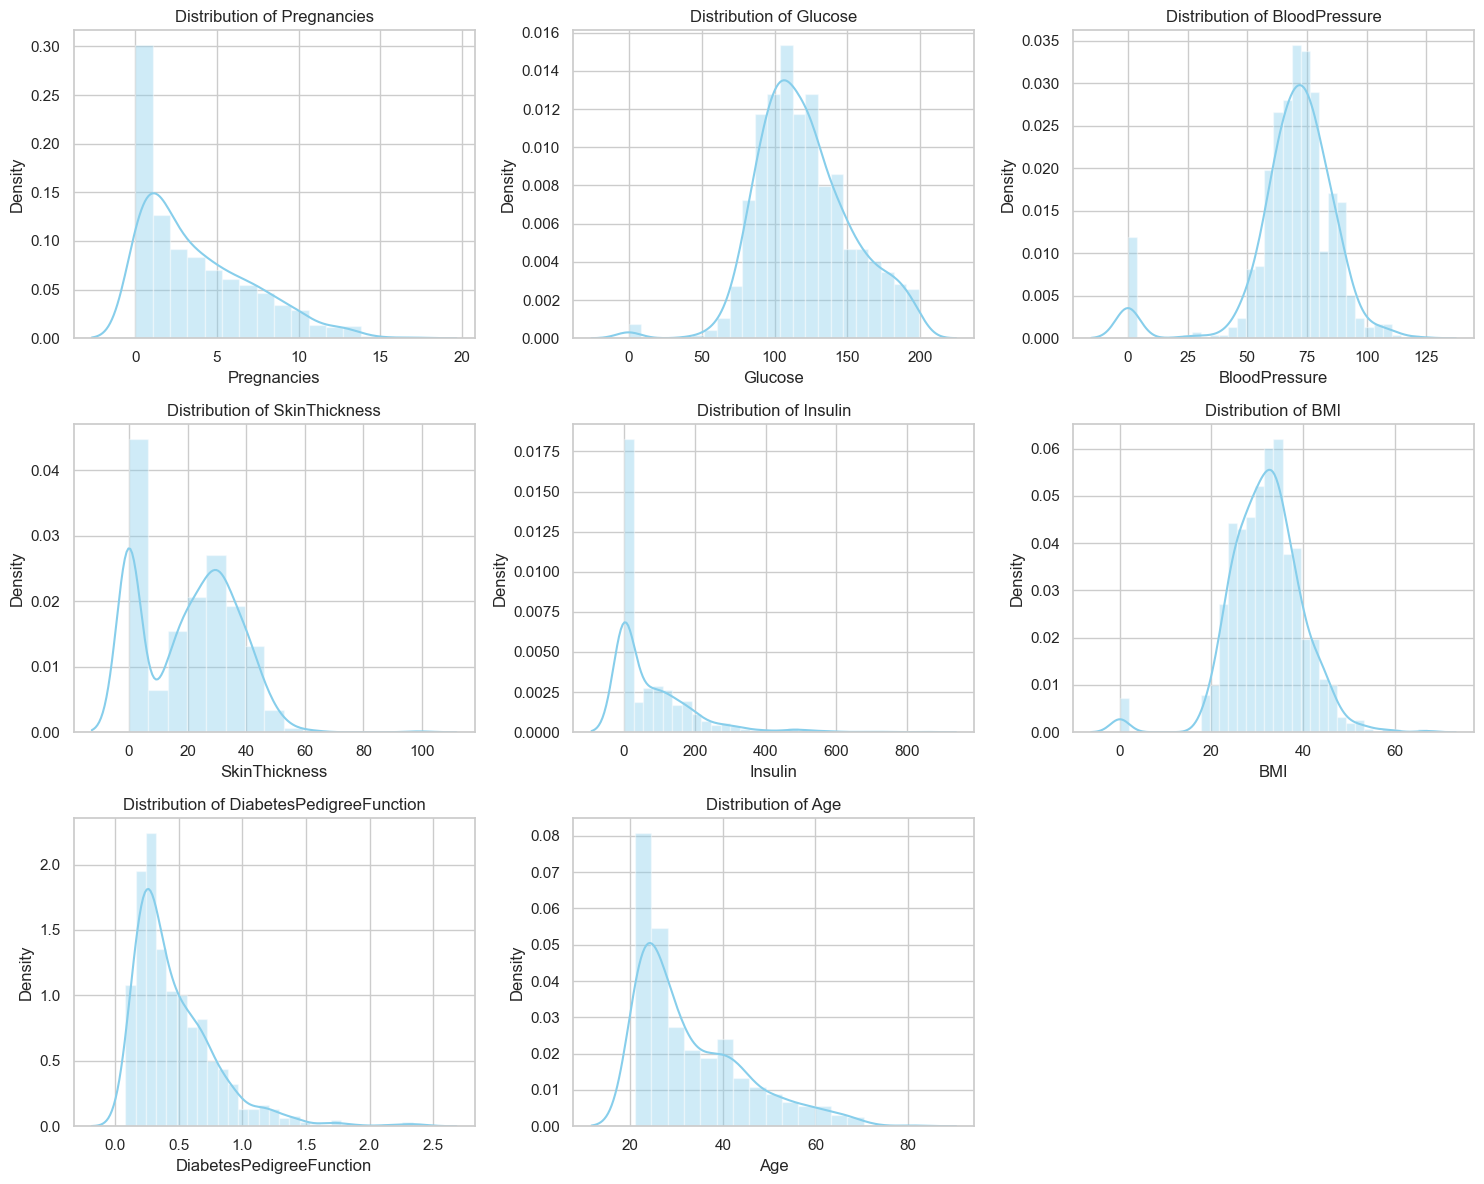

In [11]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(df.columns[:-1]): 
    plt.subplot(3, 3, i+1)
    sns.distplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

C:\Users\saipr\AppData\Local\Temp\ipykernel_5996\1650233858.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Outcome', y=col, data=df, palette='magma')
C:\Users\saipr\AppData\Local\Temp\ipykernel_5996\1650233858.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Outcome', y=col, data=df, palette='magma')
C:\Users\saipr\AppData\Local\Temp\ipykernel_5996\1650233858.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Outcome', y=col, data=df, palette='magma')
C:\Users\saipr\AppData\Local\Temp\ipykernel_5996\1650233858.py:4: FutureW

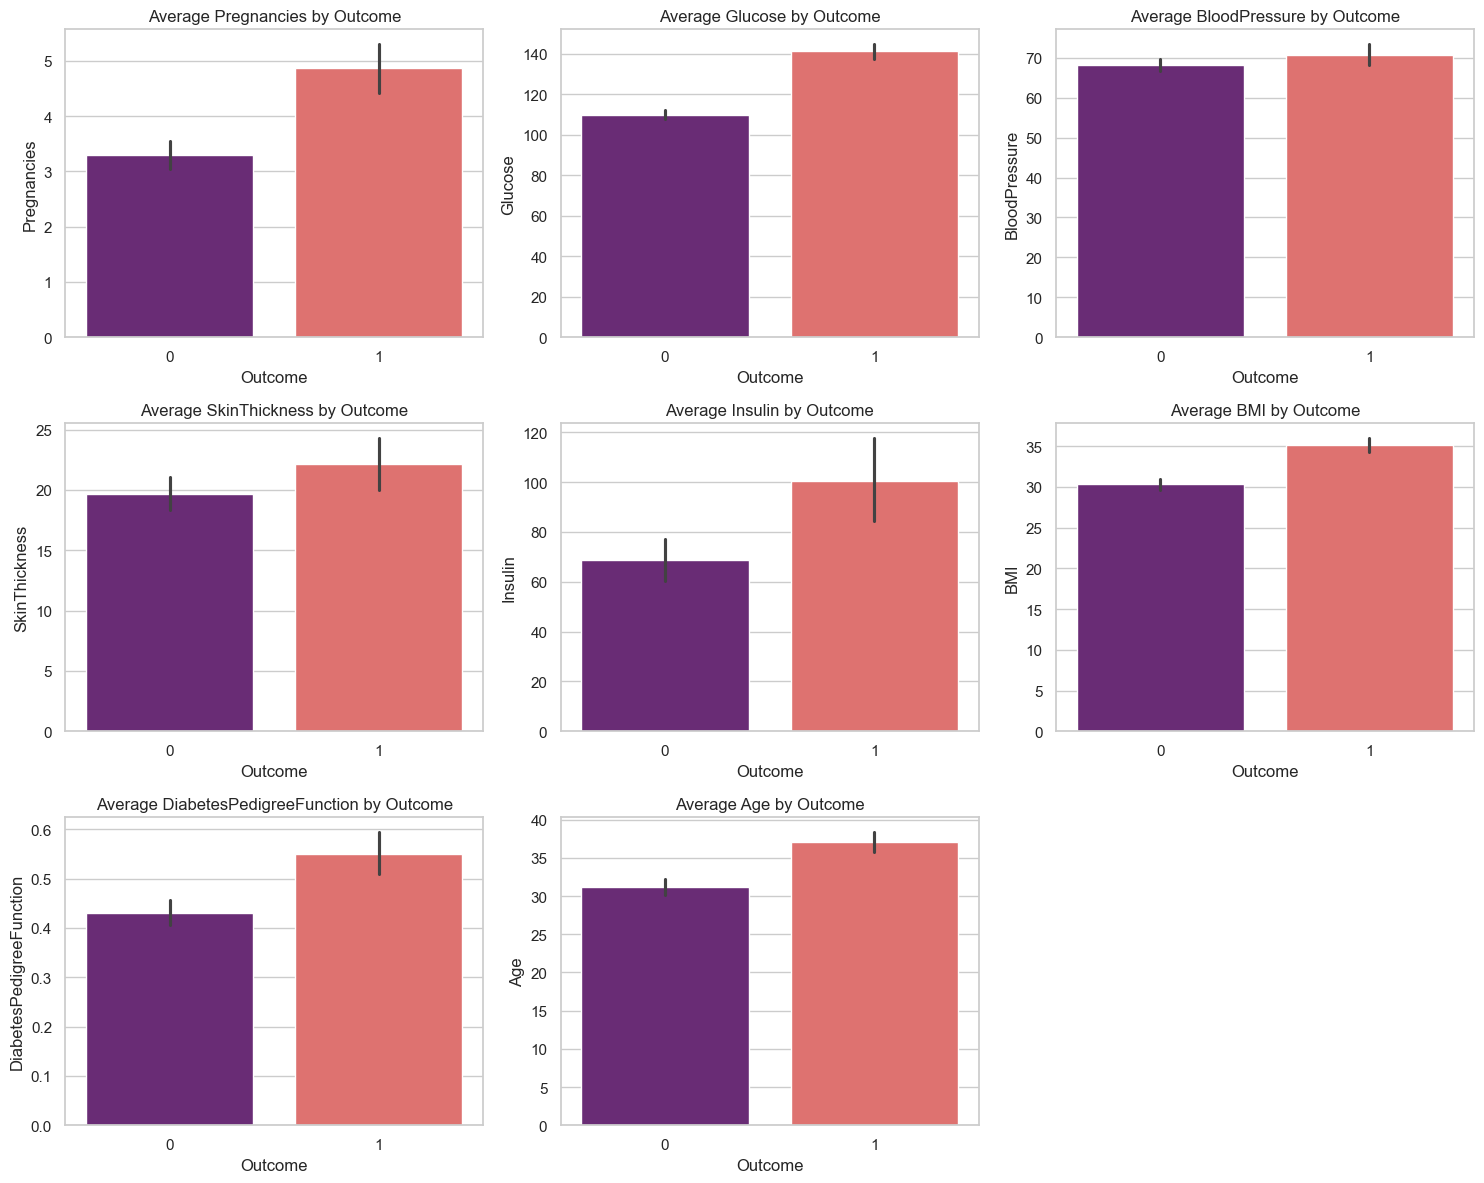

In [12]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3, 3, i+1)
    sns.barplot(x='Outcome', y=col, data=df, palette='magma')
    plt.title(f'Average {col} by Outcome')
plt.tight_layout()
plt.show()

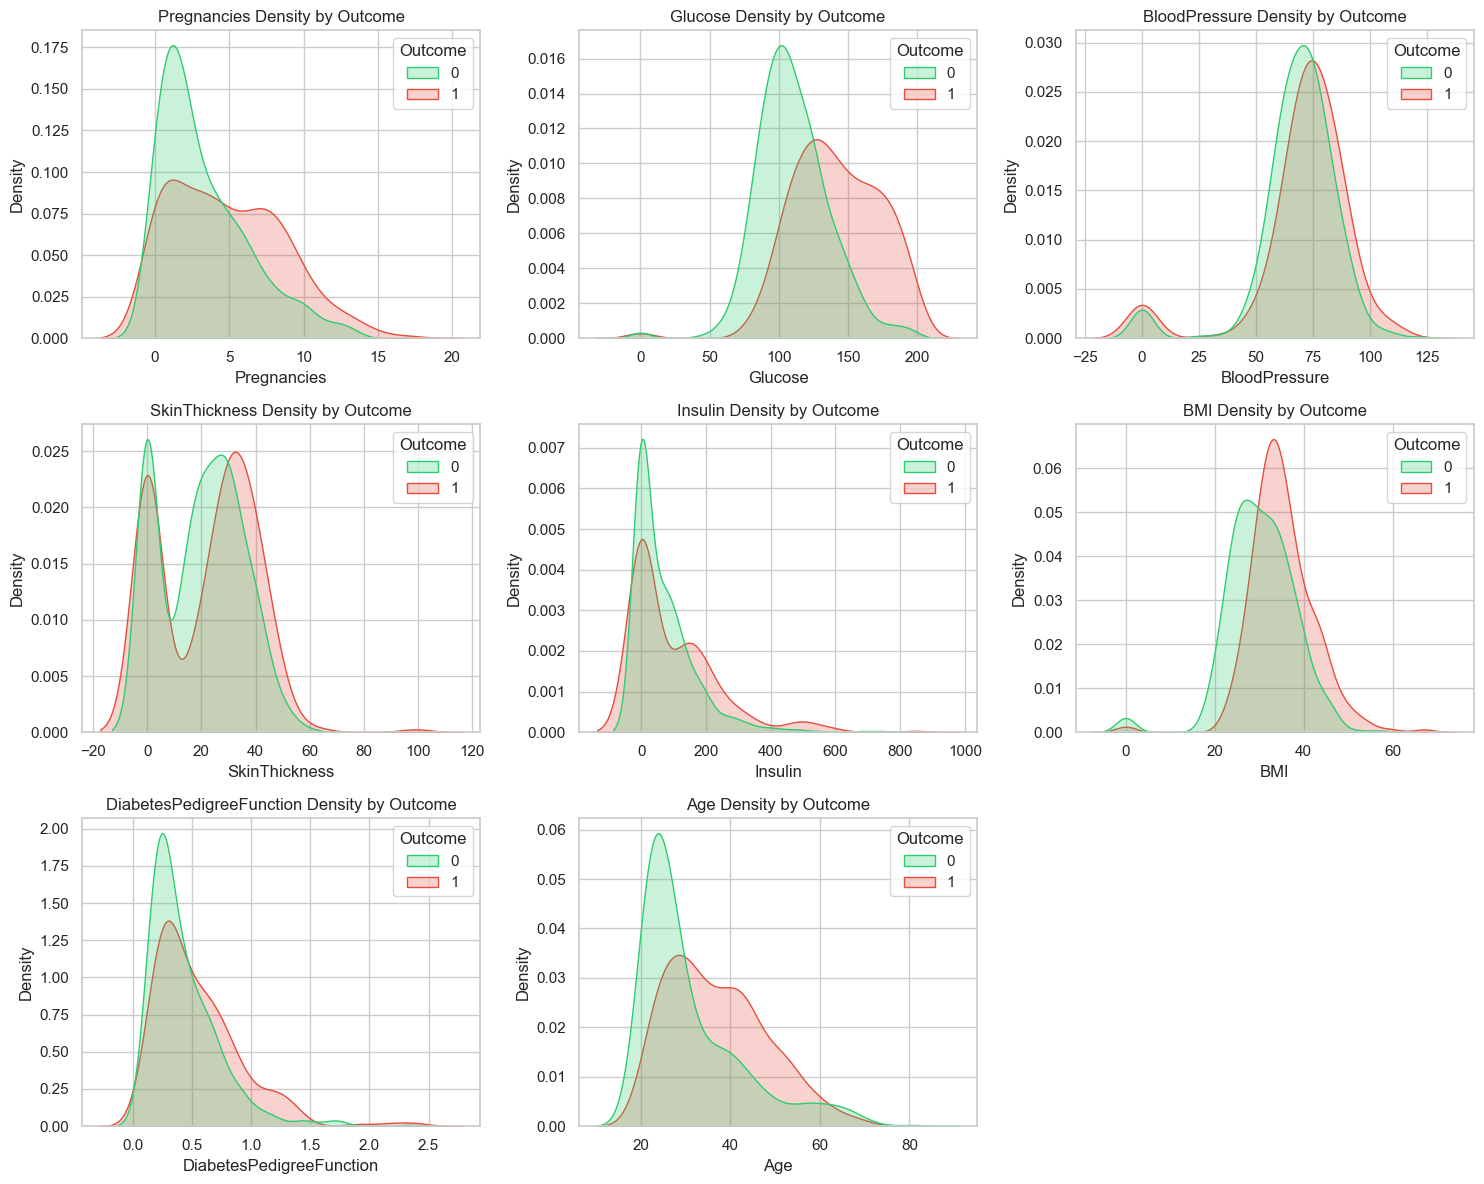

In [13]:
custom_colors = ["#2ecc71", "#e74c3c"] 

plt.figure(figsize=(15, 12))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(data=df, x=col, hue='Outcome', fill=True, common_norm=False, palette=custom_colors)
    plt.title(f'{col} Density by Outcome')
plt.tight_layout()
plt.show()

### Step 5: Exploratory Data Analysis — Feature Relationships

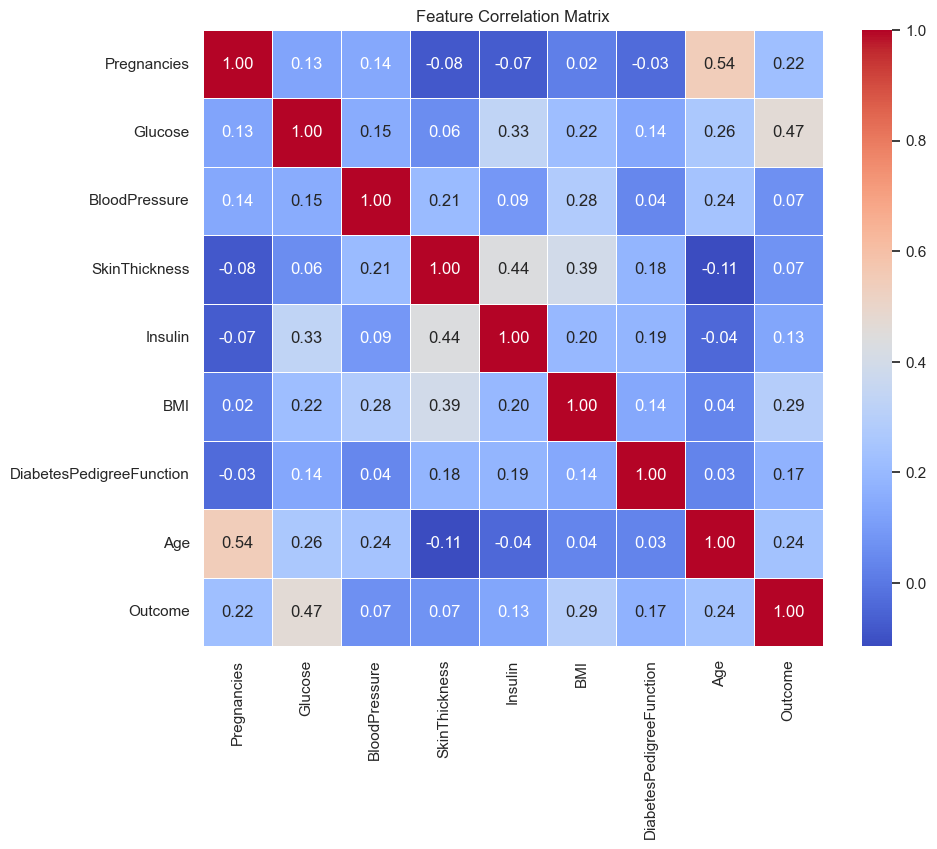

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

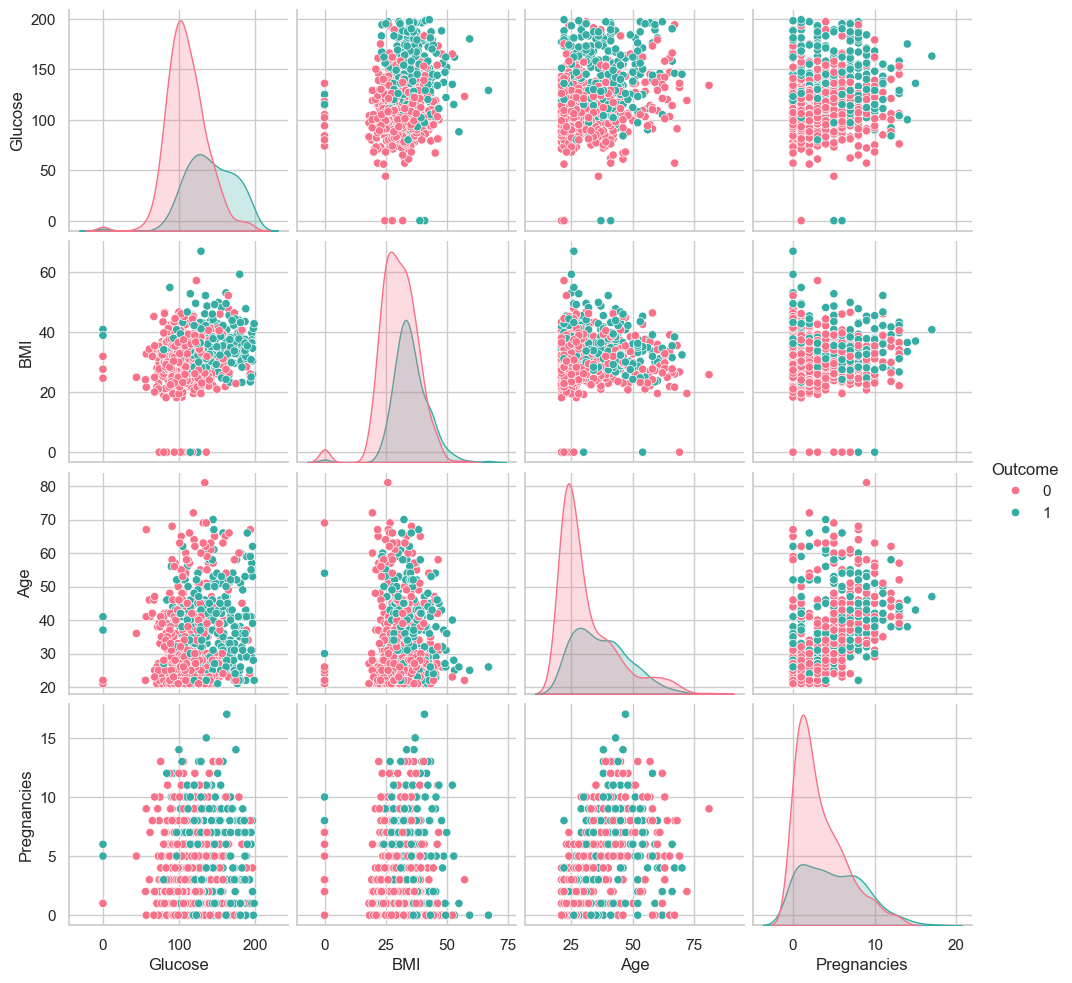

In [ ]:
important_features = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'Outcome']
sns.pairplot(df[important_features], hue='Outcome', palette='husl', diag_kind='kde')
plt.show()

C:\Users\saipr\AppData\Local\Temp\ipykernel_5996\2588947387.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\saipr\AppData\Local\Temp\ipykernel_5996\2588947387.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Non-Diabetic (0)", "Diabetic (1)"])


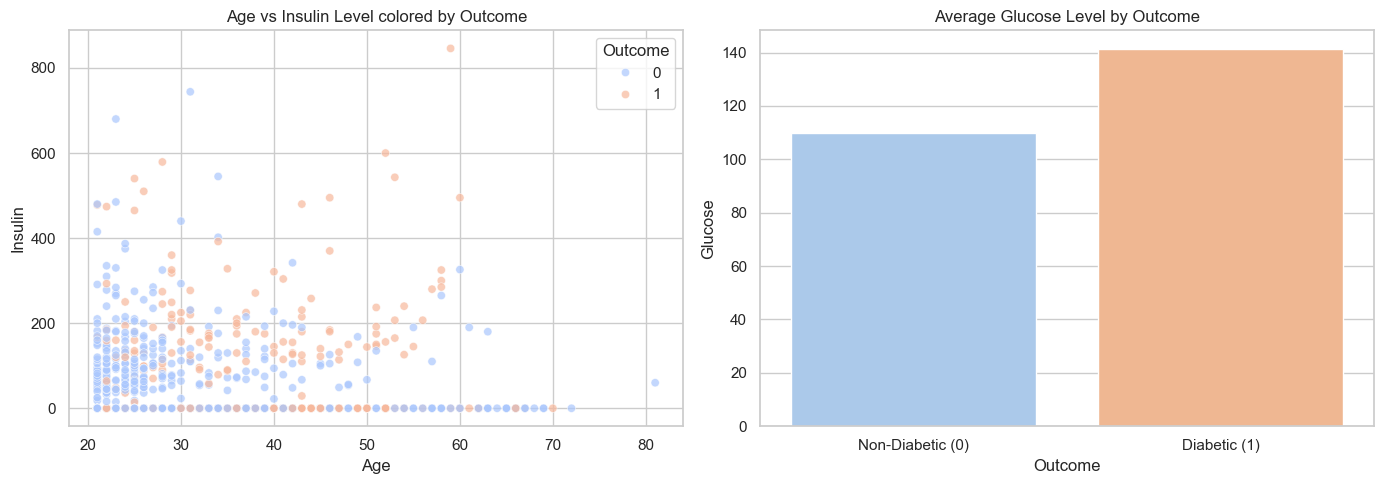

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x="Age", y="Insulin", hue="Outcome", data=df, alpha=0.7, ax=axes[0], palette="coolwarm"
)
axes[0].set_title("Age vs Insulin Level colored by Outcome")

sns.barplot(
    x="Outcome", y="Glucose", data=df, ax=axes[1], errorbar=None, palette="pastel"
)
axes[1].set_title("Average Glucose Level by Outcome")
axes[1].set_xticklabels(["Non-Diabetic (0)", "Diabetic (1)"])

plt.tight_layout()
plt.show()

### Step 6: Data Preprocessing — Imputation

In [ ]:

columns_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN
for col in columns_to_impute:
    df[col] = df[col].replace(0, np.nan)

# Impute NaNs with median values [cite: 10]
for col in columns_to_impute:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Step 7: Data Preprocessing — Categorical Encoding

In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_cols) > 0:
    print(f"Categorical columns found: {categorical_cols}. Applying One-Hot Encoding...")
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
else:
    print("No categorical text variables found; all features are already numerical.")
    df_encoded = df.copy()

df_encoded.head()

No categorical text variables found; all features are already numerical.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


### Step 8: Split Dataset into Training and Testing Sets

In [ ]:
X = df_encoded.drop(columns=["Outcome"])
y = df_encoded["Outcome"]

# Split data: 80% for training and 20% for testing [cite: 14]
# stratify=y preserves class balance across both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")

Training Set Shape: (614, 8)
Testing Set Shape: (154, 8)


### Step 9: Hyperparameter Tuning and Optimization

In [ ]:
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [50, 100, 150]
}

lgbm_base = LGBMClassifier(random_state=42, verbose=-1)
xgb_base = XGBClassifier(random_state=42, eval_metric="logloss")

print("Optimizing LightGBM via Grid Search...")
grid_lgbm = GridSearchCV(lgbm_base, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_lgbm.fit(X_train, y_train)
best_lgbm_model = grid_lgbm.best_estimator_
print(f"Best LightGBM Parameters: {grid_lgbm.best_params_}")

print("\nOptimizing XGBoost via Grid Search...")
grid_xgb = GridSearchCV(xgb_base, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_xgb.fit(X_train, y_train)
best_xgb_model = grid_xgb.best_estimator_
print(f"Best XGBoost Parameters: {grid_xgb.best_params_}")

Optimizing LightGBM via Grid Search...
Best LightGBM Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}

Optimizing XGBoost via Grid Search...
Best XGBoost Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}


### Step 10: Model Training and Prediction Evaluation

In [ ]:

# Predictions from optimized models
y_pred_lgbm = best_lgbm_model.predict(X_test)
y_pred_xgb = best_xgb_model.predict(X_test)

print("Models evaluated successfully. Ready for comparison.")

Models evaluated successfully. Ready for comparison.


### Step 11: Comparative Metrics Performance Analysis

In [ ]:

def gather_performance_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
    }

lgbm_results = gather_performance_metrics(y_test, y_pred_lgbm)
xgb_results = gather_performance_metrics(y_test, y_pred_xgb)

comparison_matrix = pd.DataFrame([lgbm_results, xgb_results], index=["LightGBM", "XGBoost"])
print("--- Evaluation Metric Performance Table ---")
comparison_matrix.round(4)

--- Evaluation Metric Performance Table ---


,Accuracy,Precision,Recall,F1-Score
LightGBM,0.7597,0.6889,0.5741,0.6263
XGBoost,0.7597,0.6889,0.5741,0.6263


In [25]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred_lgbm)

array([[86, 14],
       [23, 31]])

In [26]:
confusion_matrix(y_test,y_pred_xgb)

array([[86, 14],
       [23, 31]])

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.79      0.86      0.82       100
           1       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154



### Step 12: Performance Visualization

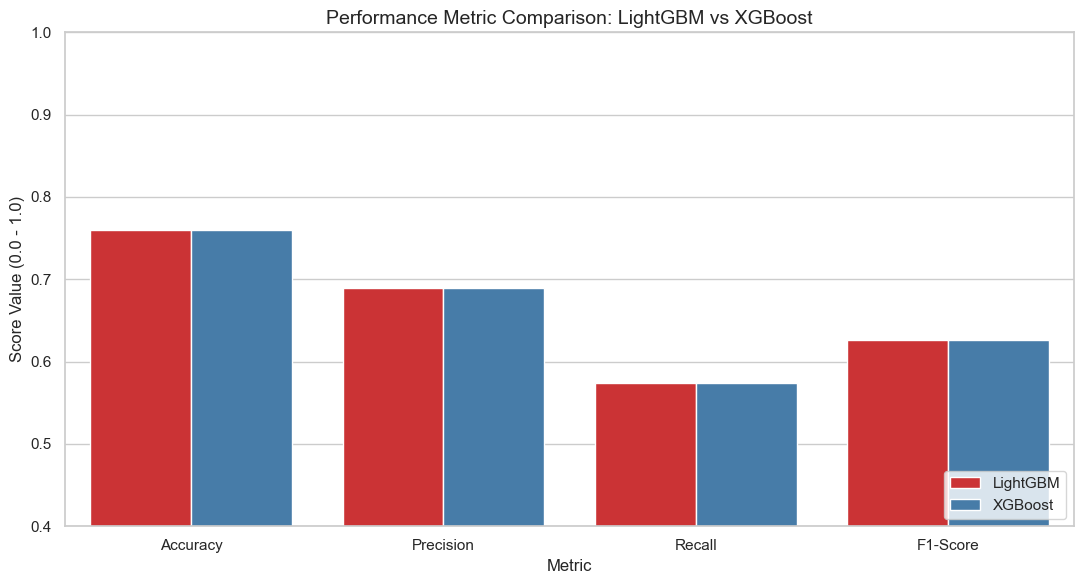

In [ ]:
melted_metrics = comparison_matrix.reset_index().melt(
    id_vars="index", var_name="Metric", value_name="Score"
)
melted_metrics.rename(columns={"index": "Algorithm"}, inplace=True)

# Generate a comparative bar plot charting all chosen metrics side-by-side [cite: 21, 24]
plt.figure(figsize=(11, 6))
sns.barplot(x="Metric", y="Score", hue="Algorithm", data=melted_metrics, palette="Set1")

plt.title("Performance Metric Comparison: LightGBM vs XGBoost", fontsize=14)
plt.ylabel("Score Value (0.0 - 1.0)")
plt.ylim(0.4, 1.0)  
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

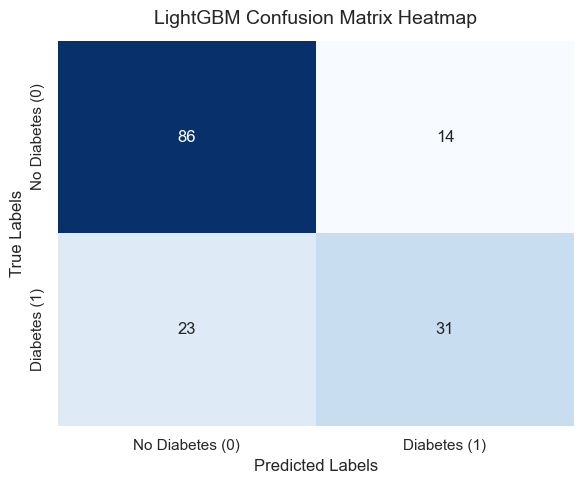

In [ ]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Diabetes (0)", "Diabetes (1)"],
    yticklabels=["No Diabetes (0)", "Diabetes (1)"],
)

plt.title("LightGBM Confusion Matrix Heatmap", fontsize=14, pad=12)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)
plt.tight_layout()
plt.show()

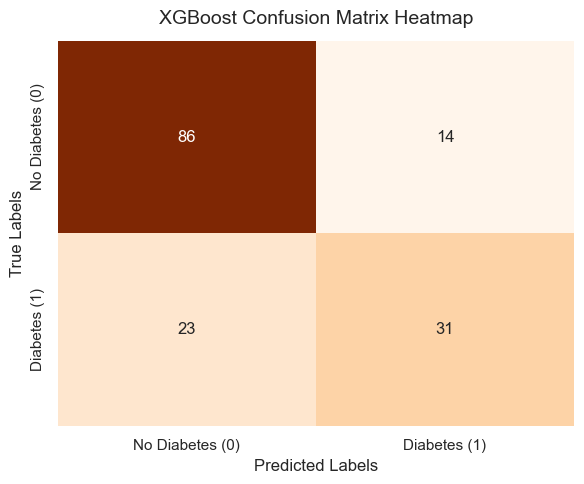

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    xticklabels=["No Diabetes (0)", "Diabetes (1)"],
    yticklabels=["No Diabetes (0)", "Diabetes (1)"],
)

plt.title("XGBoost Confusion Matrix Heatmap", fontsize=14, pad=12)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)
plt.tight_layout()
plt.show()